<a href="https://colab.research.google.com/github/iamanantalok/Master-Thesis-DES-LCA/blob/main/learning-log/01_intro_to_simpy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install simpy -q

In [ ]:
import simpy

def car(env, name):
    while True:
        print(f"{name} starts parking at {env.now}")
        parking_duration = 5
        yield env.timeout(parking_duration)

        print(f"{name} starts driving at {env.now}")
        trip_duration = 2
        yield env.timeout(trip_duration)

env = simpy.Environment()
env.process(car(env, "Car A"))
env.run(until=15)

Car A starts parking at 0
Car A starts driving at 5
Car A starts parking at 7
Car A starts driving at 12
Car A starts parking at 14


**Visit to the ATM!**

Model an ATM where a customer arrives. He spends 30 seconds to enter his details (such as PIN and amount) and it takes another 60 seconds to get the cash.

In [3]:
import simpy

env = simpy.Environment()

def customer(env):
  yield env.timeout(30)
  print(f'Details entered at time: {env.now}')
  yield env.timeout(60)
  print(f'Cash retrieved at time: {env.now}')

env.process(customer(env=env))

env.run()

Details entered at time: 30
Cash retrieved at time: 90


### Constant inter-arrival time scenario

In [4]:
import simpy

CUST_INTER_ARR_TIME = 2*60 # 2 minutes

def customer(env,name):
  print(f'{name}: Arrives at time{env.now}')
  yield env.timeout(30)
  print(f'Details entered at time: {env.now}')
  yield env.timeout(60)
  print(f'Cash retrieved at time: {env.now}')

def customer_generator(env, cust_inter_arr_time):
  cust_number = 1
  while True:
    yield env.timeout(cust_inter_arr_time)
    env.process(customer(env=env, name = f"customer{cust_number}"))
    cust_number += 1

env = simpy.Environment()

env.process(customer_generator(env=env, cust_inter_arr_time=CUST_INTER_ARR_TIME))
env.run(until=10*60) # 10 minutes

customer1: Arrives at time120
Details entered at time: 150
Cash retrieved at time: 210
customer2: Arrives at time240
Details entered at time: 270
Cash retrieved at time: 330
customer3: Arrives at time360
Details entered at time: 390
Cash retrieved at time: 450
customer4: Arrives at time480
Details entered at time: 510
Cash retrieved at time: 570


### Random inter-arrival time scenario

In [8]:
import simpy
import random

def customer(env,name):
  print(f'{name}: Arrives at time{env.now:.2f}')
  yield env.timeout(30)
  print(f'Details entered at time: {env.now:.2f}')
  yield env.timeout(60)
  print(f'Cash retrieved at time: {env.now:.2f}')

def customer_generator(env):
  cust_number = 1
  while True:
    random_inter_arr_time = random.uniform(1,3)
    yield env.timeout(random_inter_arr_time)
    env.process(customer(env=env, name = f"customer{cust_number}"))
    cust_number += 1

random.seed(2)

env = simpy.Environment()

env.process(customer_generator(env=env))

env.run(until=10*60) # 10 minutes

customer1: Arrives at time2.91
customer2: Arrives at time5.81
customer3: Arrives at time6.92
customer4: Arrives at time8.09
customer5: Arrives at time10.76
customer6: Arrives at time13.23
customer7: Arrives at time15.57
customer8: Arrives at time17.19
customer9: Arrives at time19.40
customer10: Arrives at time21.61
customer11: Arrives at time23.78
customer12: Arrives at time25.09
customer13: Arrives at time26.96
customer14: Arrives at time28.74
customer15: Arrives at time31.19
Details entered at time: 32.91
customer16: Arrives at time34.18
Details entered at time: 35.81
Details entered at time: 36.92
customer17: Arrives at time37.08
Details entered at time: 38.09
customer18: Arrives at time39.17
Details entered at time: 40.76
customer19: Arrives at time41.05
customer20: Arrives at time42.59
Details entered at time: 43.23
customer21: Arrives at time43.66
customer22: Arrives at time44.72
Details entered at time: 45.57
customer23: Arrives at time46.65
Details entered at time: 47.19
custom

### Resources

In [7]:
import simpy
import random

def customer(env, name, atm):
  print(f'{name}: Arrives at time {env.now:.2f}')
  atm_req = atm.request()
  yield atm_req
  print(f'{name}: gets ATM machine at time {env.now:.2f}')
  yield env.timeout(30)
  print(f'{name}: Details entered at time {env.now:.2f}')
  yield env.timeout(60)
  print(f'{name}: Cash retrieved at time {env.now:.2f}')
  atm.release(atm_req)

def customer_generator(env, atm):
  cust_number = 1
  while True:
    random_inter_arr_time = random.uniform(1,3)*60
    yield env.timeout(random_inter_arr_time)
    env.process(customer(env=env, name = f"customer{cust_number}", atm=atm))
    cust_number += 1

random.seed(2)

env = simpy.Environment()

atm = simpy.Resource(env, capacity=1)

env.process(customer_generator(env=env, atm=atm))

env.run(until=10*60) # 10 minutes

customer1: Arrives at time 174.72
customer1: get ATM machine at time 174.72
customer1: Details entered at time 204.72
customer1: Cash retrieved at time 264.72
customer2: Arrives at time 348.46
customer2: get ATM machine at time 348.46
customer2: Details entered at time 378.46
customer3: Arrives at time 415.25
customer2: Cash retrieved at time 438.46
customer3: get ATM machine at time 438.46
customer3: Details entered at time 468.46
customer4: Arrives at time 485.43
customer3: Cash retrieved at time 528.46
customer4: get ATM machine at time 528.46
customer4: Details entered at time 558.46


In [8]:
import simpy
import random

def customer(env, name, atm):
  print(f'{name}: Arrives at time {env.now:.2f}')
  with atm.request() as atm_req:
    yield atm_req
    print(f'{name}: get ATM machine at time {env.now:.2f}')
    yield env.timeout(30)
    print(f'{name}: Details entered at time {env.now:.2f}')
    yield env.timeout(60)
    print(f'{name}: Cash retrieved at time {env.now:.2f}')


def customer_generator(env, atm):
  cust_number = 1
  while True:
    random_inter_arr_time = random.uniform(1,3)*60
    yield env.timeout(random_inter_arr_time)
    env.process(customer(env=env, name = f"customer{cust_number}", atm=atm))
    cust_number += 1

random.seed(2)

env = simpy.Environment()

atm = simpy.Resource(env, capacity=1)

env.process(customer_generator(env=env, atm=atm))

env.run(until=10*60) # 10 minutes

customer1: Arrives at time 174.72
customer1: get ATM machine at time 174.72
customer1: Details entered at time 204.72
customer1: Cash retrieved at time 264.72
customer2: Arrives at time 348.46
customer2: get ATM machine at time 348.46
customer2: Details entered at time 378.46
customer3: Arrives at time 415.25
customer2: Cash retrieved at time 438.46
customer3: get ATM machine at time 438.46
customer3: Details entered at time 468.46
customer4: Arrives at time 485.43
customer3: Cash retrieved at time 528.46
customer4: get ATM machine at time 528.46
customer4: Details entered at time 558.46



### Simulation Performance Metrics

#### 1. Throughput Rate ($TH$)
The average rate at which entities successfully complete processing per unit time over the simulation duration.

$$\text{Throughput Rate} = \frac{N_{\text{completed}}}{T_{\text{sim}}}$$

- **$N_{\text{completed}}$:** Total number of entities successfully processed (e.g., customers who completed cash retrieval).
- **$T_{\text{sim}}$:** Total effective simulation observation duration.

---

#### 2. Cycle Time ($W$)
The total elapsed time an entity spends within the system boundary, from entry to exit. Also referred to as **Flow Time**, **Turnaround Time**, or **System Time**.

$$\text{Cycle Time} = T_{\text{departure}} - T_{\text{arrival}}$$

- **$T_{\text{departure}}$:** Timestamp when the entity leaves the system.
- **$T_{\text{arrival}}$:** Timestamp when the entity enters the system.

---

#### 3. Waiting Time ($W_q$)
The duration an entity spends waiting in the queue prior to gaining access to a processing resource. Also referred to as **Queue Time**.

$$\text{Waiting Time} = T_{\text{service\_start}} - T_{\text{arrival}}$$

- **$T_{\text{service\_start}}$:** Timestamp when the resource initiates service for the entity.
- **$T_{\text{arrival}}$:** Timestamp when the entity arrives and joins the queue.

---

#### Mathematical Relationship
At the individual entity level, Cycle Time decomposes into queueing delay and active processing duration:

$$\text{Cycle Time } (W) = \text{Waiting Time } (W_q) + \text{Service Time } (W_s)$$


### Data Analysis

In [6]:
import simpy
import random
import numpy as np


SIM_TIME = 24*60*60
WARMUP_TIME = 1*60*60

ct_simulation = []
ct_replication =[]
waiting_time_simulation = []
waiting_time_replication = []
throughput_simulation = []

def customer(env,name,atm):
  # print(f'{name}: Arrives at time {env.now:.2f}')
  customer_enter_time = env.now
  with atm.request() as atm_req:
    yield atm_req
    customer_got_atm = env.now
    # print(f'{name}: get ATM machine at time {env.now:.2f}')
    yield env.timeout(30)
    # print(f'{name}: Details entered at time {env.now:.2f}')
    yield env.timeout(60)
    # print(f'{name}: Cash retrieved at time {env.now:.2f}')

  if env.now > WARMUP_TIME:
    waiting_time_replication.append(customer_got_atm - customer_enter_time)
    ct_replication.append(env.now - customer_enter_time)

def customer_generator(env,atm):
  cust_number = 1
  while True:
    random_inter_arr_time = random.uniform(0,1)*60
    yield env.timeout(random_inter_arr_time)
    env.process(customer(env=env, name = f"customer{cust_number}", atm=atm))
    cust_number += 1


for r in range(50):
  random.seed(r)

  env = simpy.Environment()

  atm = simpy.Resource(env, capacity=1)

  env.process(customer_generator(env=env, atm=atm))

  env.run(until=SIM_TIME)

  ct_simulation.append(np.mean(ct_replication))
  waiting_time_simulation.append(np.mean(waiting_time_replication))
  num_customers = len(ct_replication)
  throughput_simulation.append(num_customers/(SIM_TIME - WARMUP_TIME))

  ct_replication = []
  waiting_time_replication = []

print(f'Average Cycle Time: {np.mean(ct_simulation)/60:.2f} minutes +/- {np.std(ct_simulation)/60:.2f} minutes'  )
print(f'Average Waiting Time: {np.mean(waiting_time_simulation)/60:.2f} minutes +/- {np.std(waiting_time_simulation)/60:.2f} minutes')
print(f'Average Throughput Rate: {np.mean(throughput_simulation)*60*60:.2f} customers/hour +/- {np.std(throughput_simulation)*60*60:.2f} customers/hour')

Average Cycle Time: 500.53 minutes +/- 5.77 minutes
Average Waiting Time: 499.03 minutes +/- 5.77 minutes
Average Throughput Rate: 40.00 customers/hour +/- 0.00 customers/hour


### Investigate how many atm to install


In [15]:
import simpy
import random
import numpy as np


SIM_TIME = 24*60*60
WARMUP_TIME = 1*60*60

ct_simulation = []
ct_replication =[]
waiting_time_simulation = []
waiting_time_replication = []
throughput_simulation = []

num_atms = [1,2,3,4,5]
ct_atms =[]
throughput_atms = []

def customer(env,name,atm):
  # print(f'{name}: Arrives at time {env.now:.2f}')
  customer_enter_time = env.now
  with atm.request() as atm_req:
    yield atm_req
    customer_got_atm = env.now
    # print(f'{name}: get ATM machine at time {env.now:.2f}')
    yield env.timeout(30)
    # print(f'{name}: Details entered at time {env.now:.2f}')
    yield env.timeout(60)
    # print(f'{name}: Cash retrieved at time {env.now:.2f}')

  if env.now > WARMUP_TIME:
    waiting_time_replication.append(customer_got_atm - customer_enter_time)
    ct_replication.append(env.now - customer_enter_time)

def customer_generator(env,atm):
  cust_number = 1
  while True:
    random_inter_arr_time = random.uniform(1,3)*60
    yield env.timeout(random_inter_arr_time)
    env.process(customer(env=env, name = f"customer{cust_number}", atm=atm))
    cust_number += 1

for atm_cap in num_atms:

  for r in range(50):
    random.seed(r)

    env = simpy.Environment()

    atm = simpy.Resource(env, capacity=atm_cap)

    env.process(customer_generator(env=env, atm=atm))

    env.run(until=SIM_TIME)

    ct_simulation.append(np.mean(ct_replication))
    waiting_time_simulation.append(np.mean(waiting_time_replication))
    num_customers = len(ct_replication)
    throughput_simulation.append(num_customers/(SIM_TIME - WARMUP_TIME))

    ct_replication = []
    waiting_time_replication = []


  # collect data per atm

  ct_atms.append(np.mean(ct_simulation)/60)
  throughput_atms.append(np.mean(throughput_simulation)*60*60)
  ct_simulation = []
  throughput_simulation = []

### PLOTS

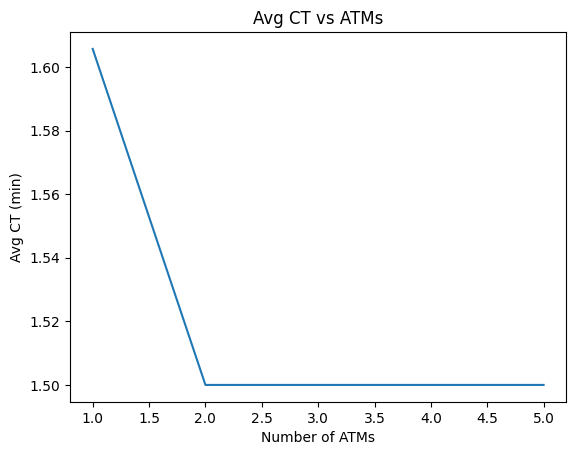

In [16]:
import matplotlib.pyplot as plt
plt.plot(num_atms, ct_atms)
plt.title(f'Avg CT vs ATMs')
plt.xlabel('Number of ATMs')
plt.ylabel('Avg CT (min)')
plt.show();

#### Let's go shopping

Assumptions:

- Customers arrive according to a Poisson arrival process with a rate of 2 customers per minute.
- The refrigerator always has milk, i.e., with infinite capacity
- Inter arrival time ~ Exponantial(2)
- Customer demand ~ Uniform [1,5] liters
- Milk fetch time = 1 minute / liter
- Number of cashier = 2
- Bill payment time = 2minute/customer

In [5]:
import simpy
import random

def customer(env,name, cashiers):
  milk_required = random.randint(1,5)
  print(f'{name}: Arrives at time {env.now:.2f}, and requires {milk_required}L milk.')
  yield env.timeout(milk_required)
  print(f'{name}: finishes retrieving the milk at time: {env.now:.2f}')
  with cashiers.request() as cashier_req:
    yield cashier_req
    print(f'{name}: starts paying the bill at time: {env.now:.2f}')
    yield env.timeout(2)
    print(f'{name}: finishes paying the bill at time: {env.now:.2f}')


def customer_generator(env, cashiers):
  cust_number = 1
  while True:
    random_inter_arr_time = random.expovariate(lambd=2)
    yield env.timeout(random_inter_arr_time)
    env.process(customer(env=env, name = f"customer {cust_number}", cashiers=cashiers))
    cust_number += 1


random.seed(2)

env = simpy.Environment()

Cashier = simpy.Resource(env=env, capacity=2)


env.process(customer_generator(env=env, cashiers=Cashier))
env.run(until=10) #10 minutes

customer 1: Arrives at time 1.56, and requires 1L milk.
customer 1: finishes retrieving the milk at time: 2.56
customer 1: starts paying the bill at time: 2.56
customer 2: Arrives at time 3.04, and requires 3L milk.
customer 3: Arrives at time 3.09, and requires 3L milk.
customer 4: Arrives at time 3.99, and requires 2L milk.
customer 5: Arrives at time 4.13, and requires 5L milk.
customer 1: finishes paying the bill at time: 4.56
customer 6: Arrives at time 4.60, and requires 4L milk.
customer 7: Arrives at time 5.17, and requires 5L milk.
customer 8: Arrives at time 5.68, and requires 5L milk.
customer 4: finishes retrieving the milk at time: 5.99
customer 4: starts paying the bill at time: 5.99
customer 2: finishes retrieving the milk at time: 6.04
customer 2: starts paying the bill at time: 6.04
customer 3: finishes retrieving the milk at time: 6.09
customer 9: Arrives at time 7.17, and requires 5L milk.
customer 4: finishes paying the bill at time: 7.99
customer 3: starts paying t

#### Container

In [3]:
import simpy
import random

def customer(env,name, cashiers,fridge):
  milk_required = random.randint(1,5)
  print(f'{name}: Arrives at time {env.now:.2f}, and requires {milk_required}L milk.')

  yield env.timeout(milk_required)
  yield fridge.get(milk_required)
  print(f'{name}: finishes retrieving the milk at time: {env.now:.2f}. Fridge has {fridge.level}L milk remaining.')
  with cashiers.request() as cashier_req:
    yield cashier_req
    print(f'{name}: starts paying the bill at time: {env.now:.2f}')
    yield env.timeout(2)
    print(f'{name}: finishes paying the bill at time: {env.now:.2f}')


def customer_generator(env, cashiers,fridge):
  cust_number = 1
  while True:
    random_inter_arr_time = random.expovariate(lambd=2)
    yield env.timeout(random_inter_arr_time)
    env.process(customer(env=env, name = f"customer {cust_number}", cashiers=cashiers, fridge=fridge))
    cust_number += 1


random.seed(2)

env = simpy.Environment()

Cashier = simpy.Resource(env=env, capacity=2)

fridge = simpy.Container(env, init=15, capacity=50)
env.process(customer_generator(env=env, cashiers=Cashier, fridge=fridge))
env.run(until=10) #10 minutes

customer 1: Arrives at time 1.56, and requires 1L milk.
customer 1: finishes retrieving the milk at time: 2.56. Fridge has 14L milk remaining.
customer 1: starts paying the bill at time: 2.56
customer 2: Arrives at time 3.04, and requires 3L milk.
customer 3: Arrives at time 3.09, and requires 3L milk.
customer 4: Arrives at time 3.99, and requires 2L milk.
customer 5: Arrives at time 4.13, and requires 5L milk.
customer 1: finishes paying the bill at time: 4.56
customer 6: Arrives at time 4.60, and requires 4L milk.
customer 7: Arrives at time 5.17, and requires 5L milk.
customer 8: Arrives at time 5.68, and requires 5L milk.
customer 4: finishes retrieving the milk at time: 5.99. Fridge has 12L milk remaining.
customer 4: starts paying the bill at time: 5.99
customer 2: finishes retrieving the milk at time: 6.04. Fridge has 9L milk remaining.
customer 2: starts paying the bill at time: 6.04
customer 3: finishes retrieving the milk at time: 6.09. Fridge has 6L milk remaining.
customer

In [13]:
import simpy
import random

def customer(env,name, cashiers,fridge):
  milk_required = random.randint(1,5)
  print(f'{name}: Arrives at time {env.now:.2f}, and requires {milk_required}L milk.')
  with fridge['resource'].request() as fridge_req:
    yield fridge_req
    yield env.timeout(milk_required)
    yield fridge['milk_container'].get(milk_required)
  print(f'{name}: finishes retrieving the milk at time: {env.now:.2f}. Fridge has {fridge["milk_container"].level}L milk remaining.')
  with cashiers.request() as cashier_req:
    yield cashier_req
    print(f'{name}: starts paying the bill at time: {env.now:.2f}')
    yield env.timeout(2)
    print(f'{name}: finishes paying the bill at time: {env.now:.2f}')


def customer_generator(env, cashiers,fridge):
  cust_number = 1
  while True:
    random_inter_arr_time = random.expovariate(lambd=2)
    yield env.timeout(random_inter_arr_time)
    env.process(customer(env=env, name = f"customer {cust_number}",
                         cashiers=cashiers, fridge=fridge))
    cust_number += 1


random.seed(2)

env = simpy.Environment()

Cashier = simpy.Resource(env=env, capacity=2)
fridge = {'resource':simpy.Resource(env=env, capacity=1), 'milk_container':simpy.Container(env, init=15, capacity=50)}

env.process(customer_generator(env=env, cashiers=Cashier, fridge=fridge))
env.run(until=10) #10 minutes

customer 1: Arrives at time 1.56, and requires 1L milk.
customer 1: finishes retrieving the milk at time: 2.56. Fridge has 14L milk remaining.
customer 1: starts paying the bill at time: 2.56
customer 2: Arrives at time 3.04, and requires 3L milk.
customer 3: Arrives at time 3.09, and requires 3L milk.
customer 4: Arrives at time 3.99, and requires 2L milk.
customer 5: Arrives at time 4.13, and requires 5L milk.
customer 1: finishes paying the bill at time: 4.56
customer 6: Arrives at time 4.60, and requires 4L milk.
customer 7: Arrives at time 5.17, and requires 5L milk.
customer 8: Arrives at time 5.68, and requires 5L milk.
customer 2: finishes retrieving the milk at time: 6.04. Fridge has 11L milk remaining.
customer 2: starts paying the bill at time: 6.04
customer 9: Arrives at time 7.17, and requires 5L milk.
customer 2: finishes paying the bill at time: 8.04
customer 10: Arrives at time 8.55, and requires 1L milk.
customer 11: Arrives at time 8.70, and requires 3L milk.
customer